In [7]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

## Task 1:

In [8]:
G = nx.Graph()

edges_data = [
    ("Oxford Circus", "Piccadilly Circus", 0.75, "peru", "-"),      
    ("Piccadilly Circus", "Charing Cross", 0.67, "peru", "-"),      
    ("Leicester Square", "Charing Cross", 0.41, "black", "-"),     
    ("Piccadilly Circus", "Leicester Square", 0.54, "blue", "-"), 
    ("Leicester Square", "Covent Garden", 0.33, "blue", "-") ]      

for u, v, w, c, s in edges_data:
    G.add_edge(u, v, distances=w, color=c, style=s)


pos = {
    "Oxford Circus": (0, 4),
    "Piccadilly Circus": (1, 2),
    "Charing Cross": (2.5, 0),
    "Leicester Square": (2.5, 2),
    "Covent Garden": (3.5, 3)
}

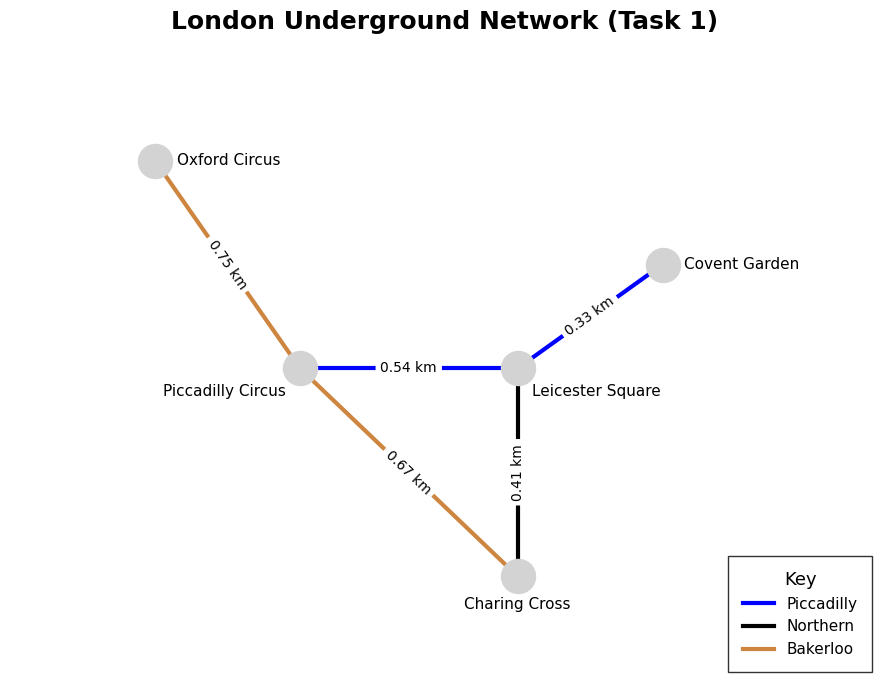

In [9]:
nodes_right = ["Oxford Circus", "Covent Garden"]
nodes_bottom_right = ["Leicester Square"]
nodes_bottom = ["Charing Cross"]
nodes_bottom_left = ["Piccadilly Circus"]

npos = {}
rotations = {}
alignments = {}


for node, (x, y) in pos.items():
    if node in nodes_right:
        npos[node] = (x + 0.15, y)
        rotations[node] = 0
        alignments[node] = ('left', 'center')
    elif node in nodes_bottom_right:
        npos[node] = (x + 0.1, y - 0.15)
        rotations[node] = 0
        alignments[node] = ('left', 'top')
    elif node in nodes_bottom:
        npos[node] = (x, y - 0.2)
        rotations[node] = 0
        alignments[node] = ('center', 'top')
    elif node in nodes_bottom_left:
        npos[node] = (x - 0.1, y - 0.15)
        rotations[node] = 0
        alignments[node] = ('right', 'top')


distances_km = {(u, v): f"{d['distances']} km" for u, v, d in G.edges(data=True)}
plt.figure(figsize=(9, 7))
nx.draw_networkx_nodes(G, pos, node_size=600, node_color='lightgray', edgecolors='lightgray')
for (u, v, d) in G.edges(data=True):
    nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], edge_color=d['color'], style=d['style'], width=3)

nx.draw_networkx_edge_labels(G, pos, edge_labels=distances_km, font_size=10, label_pos=0.5)


text_items = nx.draw_networkx_labels(G, npos, font_size=11, font_family='sans-serif')
for node, text_obj in text_items.items():
    text_obj.set_rotation(rotations[node])
    text_obj.set_horizontalalignment(alignments[node][0])
    text_obj.set_verticalalignment(alignments[node][1])


plt.plot([], [], color='blue', linewidth=3, linestyle='-', label='Piccadilly')
plt.plot([], [], color='black', linewidth=3, linestyle='-', label='Northern')
plt.plot([], [], color='peru', linewidth=3, linestyle='-', label='Bakerloo')

plt.legend(loc='lower right', title='Key', fontsize=11, title_fontsize=13, 
           frameon=True, edgecolor='black', fancybox=False, borderpad=1)

plt.xlim(-1, 5)
plt.ylim(-1, 5)
plt.axis('off')
plt.title("London Underground Network (Task 1)", fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## Task 2:

In [ ]:
G = nx.Graph()

# Central 
central = [("Notting Hill Gate", "Queensway", 0.57), ("Queensway", "Lancaster Gate", 0.93), 
           ("Lancaster Gate", "Marble Arch", 1.2), ("Marble Arch", "Bond Street", 0.6), 
           ("Bond Street", "Oxford Circus", 0.52)]

# Victoria 
victoria = [("Victoria", "Green Park", 1.3), ("Green Park", "Oxford Circus", 0.9), 
            ("Oxford Circus", "Warren Street", 1.1), ("Warren Street", "Euston", 0.6), 
            ("Euston", "King's Cross", 0.8)]

# Bakerloo 
bakerloo = [("Paddington", "Baker Street", 1.44), ("Baker Street", "Regent's Park", 0.78), 
            ("Regent's Park", "Oxford Circus", 0.99), ("Oxford Circus", "Piccadilly Circus", 0.74), 
            ("Piccadilly Circus", "Charing Cross", 0.7)]

# Jubilee 
jubilee = [("Baker Street", "Bond Street", 1.12), ("Bond Street", "Green Park", 0.92), 
           ("Green Park", "Westminster", 1.4), ("Westminster", "Waterloo", 0.85), 
           ("Waterloo", "London Bridge", 1.82)]

# Piccadilly 
piccadilly = [("South Kensington", "Knightsbridge", 1.24), ("Knightsbridge", "Hyde Park Corner", 0.6), 
              ("Hyde Park Corner", "Green Park", 0.78), ("Green Park", "Piccadilly Circus", 0.61), 
              ("Piccadilly Circus", "Covent Garden", 0.86)]

for u, v, w in central: G.add_edge(u, v, weight=w, color="#DC241f")   
for u, v, w in victoria: G.add_edge(u, v, weight=w, color="#0098D4") 
for u, v, w in bakerloo: G.add_edge(u, v, weight=w, color="#B36305")  
for u, v, w in jubilee: G.add_edge(u, v, weight=w, color="#868F98")    
for u, v, w in piccadilly: G.add_edge(u, v, weight=w, color="#0019A8")


pos = {
    # Central
    "Notting Hill Gate": (-4, 0), "Queensway": (-3, 0), "Lancaster Gate": (-2, 0),
    "Marble Arch": (-1, 0), "Bond Street": (0, 0), "Oxford Circus": (2, 0),
    
    # Victoria
    "Victoria": (-1, -3), "Green Park": (0, -1.5), "Warren Street": (3, 1),
    "Euston": (4, 2), "King's Cross": (5, 3),
    
    # Bakerloo
    "Paddington": (1, 3), "Baker Street": (1, 1.5), "Regent's Park": (1.5, 0.75),
    "Piccadilly Circus": (2.5, -1.5), "Charing Cross": (3, -2.5),
    
    # Jubilee
    "Westminster": (1, -3), "Waterloo": (2, -4), "London Bridge": (3, -4),
    
    # Piccadilly
    "South Kensington": (-3, -3), "Knightsbridge": (-2, -2.5), 
    "Hyde Park Corner": (-1, -2), "Covent Garden": (4, -1.5)
}

<Figure size 1600x1100 with 0 Axes>

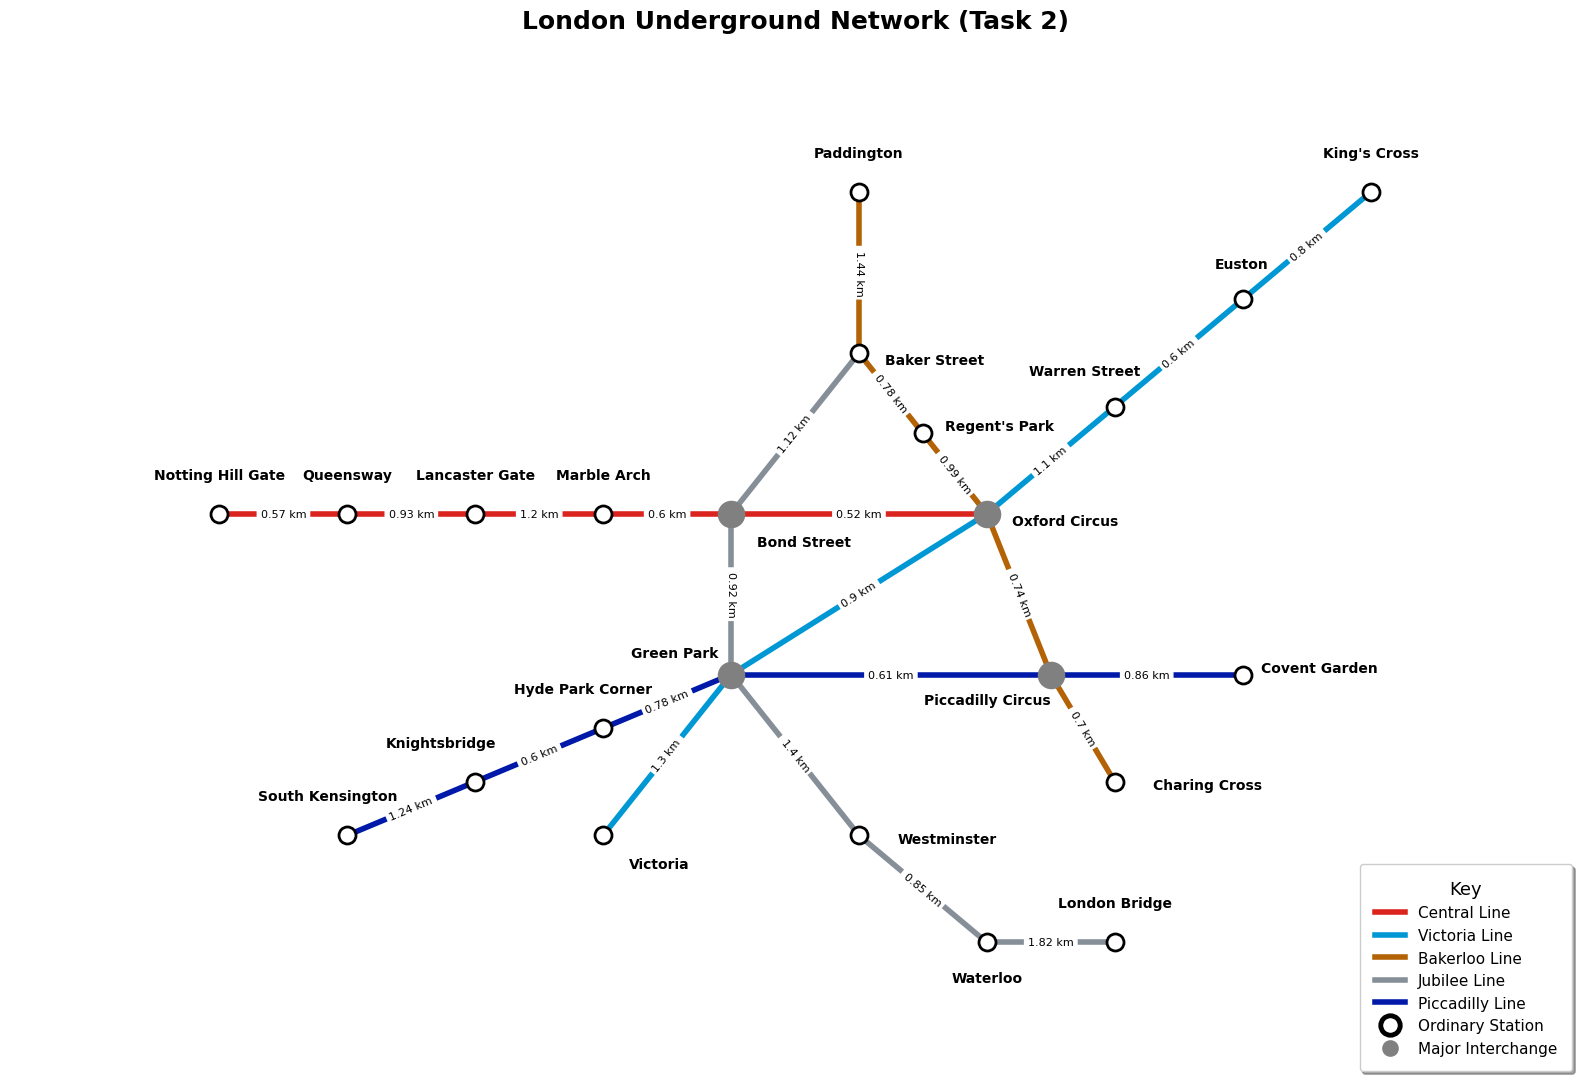

In [ ]:
pos_labels = {}
rotations = {}
alignments = {}

for node, (x, y) in pos.items():
    if node in ["Notting Hill Gate", "Queensway", "Lancaster Gate", "Marble Arch", "King's Cross", "London Bridge", "Paddington"]:
        pos_labels[node] = (x, y + 0.3)
        rotations[node] = 0
        alignments[node] = ('center', 'bottom')
        
    elif node in ["Westminster", "Charing Cross"]:
        pos_labels[node] = (x + 0.3, y - 0.1)
        rotations[node] = 0
        alignments[node] = ('left', 'bottom')
        
    elif node in ["Covent Garden", "Regent's Park"]: 
        pos_labels[node] = (x + 0.6, y)
        rotations[node] = 0
        alignments[node] = ('center', 'bottom')
        
    elif node in ["South Kensington", "Knightsbridge", "Hyde Park Corner"]:
        pos_labels[node] = (x - 0.7, y + 0.3)
        rotations[node] = 0
        alignments[node] = ('left', 'bottom')

    elif node in ["Baker Street", "Oxford Circus"]:
        pos_labels[node] = (x + 0.2, y)
        rotations[node] = 0
        alignments[node] = ('left', 'top')

    elif node in ["Piccadilly Circus"]:
        pos_labels[node] = (x, y - 0.3)
        rotations[node] = 0
        alignments[node] = ('right', 'bottom')

    elif node in ["Green Park"]:
        pos_labels[node] = (x - 0.1, y + 0.2)
        rotations[node] = 0
        alignments[node] = ('right', 'center')
        
    elif node in [ "Bond Street", "Victoria"]:
        pos_labels[node] = (x + 0.2, y - 0.2)
        rotations[node] = 0
        alignments[node] = ('left', 'top')

    elif node in ["Euston", "Warren Street"]:
        pos_labels[node] = (x + 0.2, y + 0.4)
        rotations[node] = 0
        alignments[node] = ('right', 'top')

    elif node in ["Waterloo"]:
        pos_labels[node] = (x, y - 0.4)
        rotations[node] = 0
        alignments[node] = ('center', 'bottom')


edges = G.edges()
colors = [G[u][v]['color'] for u, v in edges]
distances_km = {(u, v): f"{d['weight']} km" for u, v, d in G.edges(data=True)}


plt.figure(figsize=(16, 11))


main_4_stations = ["Bond Street", "Oxford Circus", "Green Park", "Piccadilly Circus"]
ordinary_stations = [node for node in G.nodes() if node not in main_4_stations]


main_station_colors = {}
for node in main_4_stations:
    connected_edges = G.edges(node, data=True)
    for u, v, d in connected_edges:
        main_station_colors[node] = d['color']
        break

plt.figure(figsize=(16, 11))


nx.draw_networkx_edges(G, pos, edge_color=colors, width=4)
nx.draw_networkx_edge_labels(G, pos, edge_labels=distances_km, font_size=8)


nx.draw_networkx_nodes(G, pos, nodelist=ordinary_stations, node_size=150, 
                       node_color='white', edgecolors='black', linewidths=2)


for node, color in main_station_colors.items():
    nx.draw_networkx_nodes(G, pos, nodelist=[node], node_size=300, 
                           node_color='gray', edgecolors='gray', linewidths=2.5)


text_items = nx.draw_networkx_labels(G, pos_labels, font_size=10, font_weight='bold')
for node, text_obj in text_items.items():
    text_obj.set_rotation(rotations[node])
    text_obj.set_horizontalalignment(alignments[node][0])
    text_obj.set_verticalalignment(alignments[node][1])


plt.plot([], [], color='#DC241f', linewidth=4, label='Central Line')
plt.plot([], [], color='#0098D4', linewidth=4, label='Victoria Line')
plt.plot([], [], color='#B36305', linewidth=4, label='Bakerloo Line')
plt.plot([], [], color='#868F98', linewidth=4, label='Jubilee Line')
plt.plot([], [], color='#0019A8', linewidth=4, label='Piccadilly Line')


plt.plot([], [], color='none', marker='o', markerfacecolor='white', 
         markeredgecolor='black', markeredgewidth=3.5, markersize=14, label='Ordinary Station')
plt.plot([], [], color='none', marker='o', markerfacecolor='gray', 
         markeredgecolor='gray', markeredgewidth=2.0, markersize=10, label='Major Interchange')

plt.legend(loc='lower right', title='Key', fontsize=11, title_fontsize=13, shadow=True, borderpad=1)
plt.title("London Underground Network (Task 2)", fontsize=18, fontweight='bold', pad=20)
plt.margins(0.12)
plt.axis('off')
plt.tight_layout()
plt.show()

In [12]:

distances = list(nx.get_edge_attributes(G, 'weight').values())


total_length = np.sum(distances)
average_distance = np.mean(distances)
std_deviation = np.std(distances)


print("-" * 50)
print("--- RESULT DATA TASK 3 (LONDON UNDERGROUND) ---")
print("-" * 50)
print(f"1. Total length of the transport network: {total_length:.2f} km")
print(f"2. The average distance between the stations: {average_distance:.2f} km")
print(f"3. The standard deviation of the distances between the stations: {std_deviation:.2f} km")

--------------------------------------------------
--- RESULT DATA TASK 3 (LONDON UNDERGROUND) ---
--------------------------------------------------
1. Total length of the transport network: 23.37 km
2. The average distance between the stations: 0.93 km
3. The standard deviation of the distances between the stations: 0.32 km
